In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SelectKBest with f_classif runs an ANOVA F-test between each feature
# and the binary target. This is a fast, well-understood filter method
# suitable for large tabular datasets like CIC-IDS-2017.
from sklearn.feature_selection import SelectKBest, f_classif


In [2]:
# Load the cleaned dataset produced by the ETL pipeline.
# At this stage the data has already been de-duplicated of obvious
# quality issues (inf values removed, missing rows dropped, Label binarised).
df = pd.read_csv("../data/processed/cleaned_data.csv")
print("Dataset loaded successfully")


Dataset loaded successfully


In [3]:
# Basic structural checks to confirm the ETL output is as expected.
# Verifying shape, column count, and data types catches any silent
# failures in the pipeline before downstream analysis.
print("=== Dataset Overview ===")
print("Shape:", df.shape)
print("Number of columns:", len(df.columns))
print("Last column:", df.columns[-1])
df.head()

print(f"Total rows: {df.shape[0]:,}")
print("
Column Names:")
print(df.columns.tolist())

# dtypes.value_counts() shows whether all features are numeric,
# which is required before passing the data into sklearn.
print("
Data Types:")
print(df.dtypes.value_counts())


=== Dataset Overview ===
Shape: (2827876, 79)
Number of columns: 79
Last column: Label
Total rows: 2,827,876

Column Names:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',

### Observation
The processed dataset contains 2,827,876 rows and 79 columns, with `Label` as the target variable.  
All features are numerical (`int64` or `float64`), which confirms that the dataset is already in a machine-learning-ready tabular format. This is an important outcome of the ETL process, since raw intrusion data often requires cleaning and type standardization before analysis.

In [4]:
# Inspect class balance to understand the severity of imbalance.
# In network traffic data, benign flows vastly outnumber attacks,
# so the ratio informs whether resampling or class-weighted training
# will be needed in Phase 2.
print("Label distribution:")
print(df["Label"].value_counts())

print("
Label percentages:")
print((df["Label"].value_counts(normalize=True) * 100).round(2))


Label distribution:
0    2271320
1     556556
Name: Label, dtype: int64

Label percentages:
0    80.32
1    19.68
Name: Label, dtype: float64


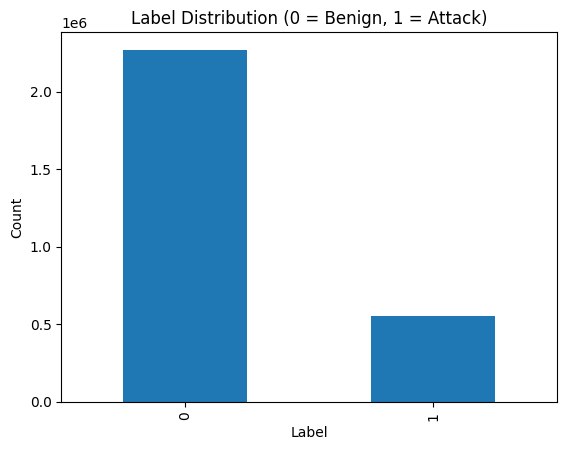

In [5]:
# Visual representation of class imbalance.
# A bar chart communicates the scale of the imbalance more immediately
# than raw counts and is useful for reporting.
df["Label"].value_counts().plot(kind="bar")
plt.title("Label Distribution (0 = Benign, 1 = Attack)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


In [6]:
print("
=== Duplicate Check ===")

# Count exact-row duplicates. In network traffic, repeated flows
# are plausible (e.g., retransmissions or scanner loops), so duplicates
# are recorded here but not removed — removal could distort class ratios.
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")



=== Duplicate Check ===
Duplicate rows: 307078


### Duplicate Handling Decision

Duplicate rows were identified in the dataset; however, they were not removed.

In the context of network intrusion detection, duplicate records may represent repeated network flows or recurring attack patterns, which are meaningful and expected in real-world traffic data.

Removing duplicates could distort the natural distribution of the dataset and eliminate important behavioral patterns, especially for malicious activity.

Therefore, duplicates are retained to preserve the integrity and realism of the dataset.


In [7]:
# Verify that no missing values survived the ETL cleaning step.
# The ETL pipeline replaced inf values and dropped null rows;
# this check confirms the guarantee holds before feature selection.
print("Total missing values:", df.isna().sum().sum())


Total missing values: 0


In [8]:
# Descriptive statistics reveal the scale and spread of each feature.
# Large differences in magnitude across features may indicate the need
# for normalization depending on the model chosen in Phase 2.
df.describe()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
count,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,...,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06
mean,8.061534e+03,1.480065e+07,9.368972e+00,1.040396e+01,5.498522e+02,1.617903e+04,2.078044e+02,1.872929e+01,5.825628e+01,6.897811e+01,...,-2.744494e+03,8.163400e+04,4.117582e+04,1.533378e+05,5.835492e+04,8.324468e+06,5.043548e+05,8.704568e+06,7.928061e+06,1.968106e-01
std,1.827432e+04,3.366750e+07,7.500527e+02,9.978937e+02,9.998639e+03,2.264235e+06,7.175183e+02,6.035533e+01,1.861733e+02,2.813212e+02,...,1.085539e+06,6.489234e+05,3.935787e+05,1.026333e+06,5.773818e+05,2.364057e+07,4.605289e+06,2.437766e+07,2.337390e+07,3.975880e-01
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,2.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.133800e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.239368e+06,5.000000e+00,4.000000e+00,1.880000e+02,4.840000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08,1.000000e+00



=== Focused Correlation Analysis ===


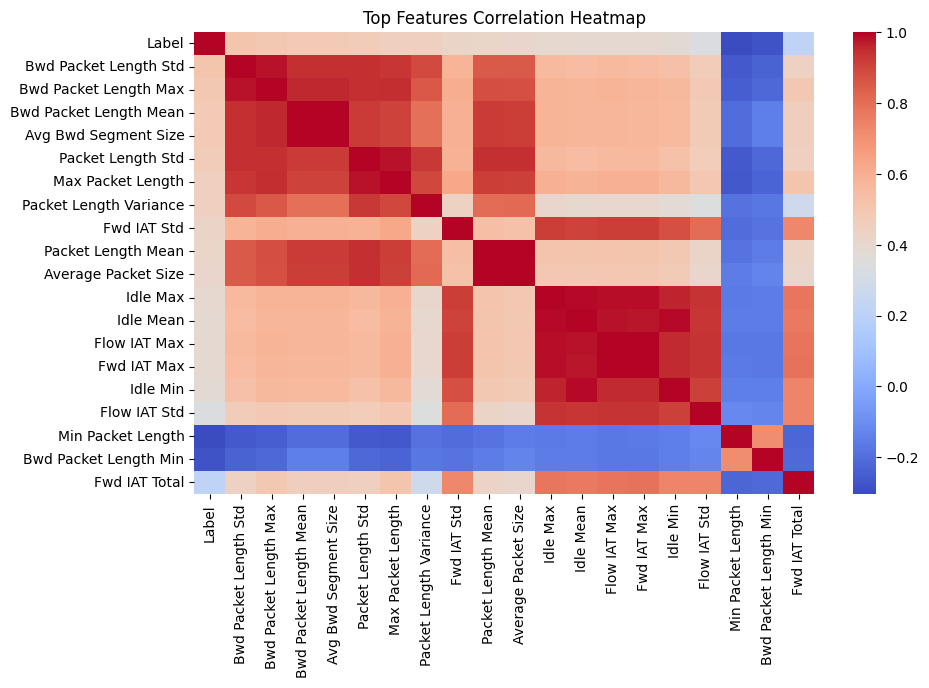

In [9]:
import seaborn as sns

print("
=== Focused Correlation Analysis ===")

# Compute pairwise correlation and rank features by absolute correlation
# with the target label. Examining the top 20 avoids visual clutter
# while still covering the most informative subset.
corr = df.corr()
top_features = corr["Label"].abs().sort_values(ascending=False).head(20).index

# A heatmap of the top features highlights multicollinearity,
# which justifies applying feature selection to reduce redundancy.
plt.figure(figsize=(10, 6))
sns.heatmap(df[top_features].corr(), cmap='coolwarm', annot=False)
plt.title("Top Features Correlation Heatmap")
plt.show()


In [10]:
X = df.drop("Label", axis=1)
y = df["Label"]

# Drop constant columns (zero variance) before feature selection.
# Features with a single unique value carry no information and would
# produce NaN F-scores in the ANOVA test, causing sklearn warnings.
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
print("Constant columns removed:", constant_cols)

X = X.drop(columns=constant_cols)
print("Shape after removing constant columns:", X.shape)


Constant columns removed: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Shape after removing constant columns: (2827876, 70)


In [11]:
# ANOVA F-test (f_classif) measures the linear relationship between
# each feature and the binary label. k=15 was chosen as a balance
# between retaining enough signal and keeping the feature set compact
# for efficient training in Phase 2.
selector = SelectKBest(score_func=f_classif, k=15)
X_new = selector.fit_transform(X, y)

# Retrieve the column names of the selected features for traceability.
selected_features = X.columns[selector.get_support()]

print("Selected features:")
print(selected_features)


Selected features:
Index(['Bwd Packet Length Max', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Std', 'Fwd IAT Max',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size',
       'Idle Mean', 'Idle Max', 'Idle Min'],
      dtype='object')


### Feature Selection

Feature selection was performed using the ANOVA F-test (`f_classif`) through the `SelectKBest` method to identify the most relevant features for predicting the target variable (`Label`).

The ANOVA F-test evaluates the statistical relationship between each feature and the target by comparing variance between classes (benign vs attack) to variance within classes. Features with higher F-scores are considered more discriminative.

A total of 15 top-performing features were selected based on their statistical significance.

The selected features primarily capture:
- packet size characteristics (e.g., packet length metrics)
- timing behavior (e.g., inter-arrival times)
- flow activity patterns (e.g., idle time statistics)

These features are aligned with the project objective of detecting anomalous network behavior, as they reflect key differences between normal and malicious traffic patterns.

Feature selection helps to:
- reduce dimensionality
- eliminate redundant or less informative features
- improve model efficiency and generalization

The resulting subset of features forms the curated dataset used for downstream machine learning tasks in Phase 2.


In [12]:
# Combine the selected features with the label column to form
# the curated dataset that Phase 2 will use for model training.
df_selected = df[selected_features.tolist() + ["Label"]]

# Save to the curated zone; the path follows the three-layer
# storage architecture (raw -> processed -> curated).
df_selected.to_csv("../data/curated/selected_features.csv", index=False)

print("Curated dataset saved successfully")
print("Curated shape:", df_selected.shape)


Curated dataset saved successfully
Curated shape: (2827876, 16)


In [13]:
# Quick sanity check on the first few rows of the curated dataset
# to confirm the correct columns and label values were saved.
df_selected.head()


,Bwd Packet Length Max,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Max,Fwd IAT Std,Fwd IAT Max,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,Average Packet Size,Avg Bwd Segment Size,Idle Mean,Idle Max,Idle Min,Label
0,0,0.0,0.0,3,0.0,3,6,6.0,0.0,0.0,9.0,0.0,0.0,0,0,0
1,6,6.0,0.0,109,0.0,0,6,6.0,0.0,0.0,9.0,6.0,0.0,0,0,0
2,6,6.0,0.0,52,0.0,0,6,6.0,0.0,0.0,9.0,6.0,0.0,0,0,0
3,6,6.0,0.0,34,0.0,0,6,6.0,0.0,0.0,9.0,6.0,0.0,0,0,0
4,0,0.0,0.0,3,0.0,3,6,6.0,0.0,0.0,9.0,0.0,0.0,0,0,0


In [14]:
# Print the exact column list saved in the curated dataset.
# This list serves as the feature contract between Phase 1 and Phase 2:
# the training script expects exactly these columns in this order.
print("Selected feature dataset columns:")
print(df_selected.columns.tolist())


Selected feature dataset columns:
['Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Std', 'Fwd IAT Max', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size', 'Idle Mean', 'Idle Max', 'Idle Min', 'Label']


## Exploratory Analysis Summary

A concise exploratory analysis was conducted to evaluate the quality and readiness of the processed dataset for machine learning.

### 1. Data Distribution
Feature distributions reveal that most variables are highly skewed, with values concentrated near zero and long tails of extreme values. This is expected in network traffic data, where the majority of flows are small, and a few are significantly larger.

### 2. Correlation Analysis
Correlation analysis showed that several features are strongly related to each other, indicating potential redundancy. This justified the application of feature selection to reduce dimensionality and improve model efficiency.

### 3. Outlier Analysis
Outliers were detected across multiple features. These extreme values were not removed, as they may represent abnormal or malicious network behavior. Retaining them ensures that the dataset reflects real-world conditions and preserves important patterns for intrusion detection.

### 4. Data Quality Assessment
- No missing values remain after ETL processing
- A significant number of duplicate rows were identified and retained to preserve realistic traffic patterns
- All features are numerical, making the dataset suitable for machine learning models

### 5. Potential Data Risks
- Class imbalance (more benign than attack samples) may bias model predictions
- Highly skewed feature distributions may require scaling
- Correlated features may introduce redundancy
- Extreme values (outliers) may influence certain models

### 6. Data Readiness
Based on the analysis, the dataset is considered suitable for machine learning.

The data has been:
- cleaned and validated
- analyzed for quality issues
- reduced to relevant features

The curated dataset is now ready for use in Phase 2 for model training and evaluation.
